In [47]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from umap import UMAP

In [18]:
file = h5py.File("/Volumes/SSD/data/hlca_50pc_50k.hdf5")
adata = sc.read_h5ad("/Volumes/SSD/data/hlca.h5ad", 'r')

In [19]:
df = pd.DataFrame({
    "total_dist": file["total_dist"],
    "cell_type": adata.obs["cell_type"],
    "disease": adata.obs["disease"]
})

In [20]:
dist_by_cell = df.groupby("cell_type", as_index=False)["total_dist"].mean()
dist_by_disease = df.groupby("disease", as_index=False)["total_dist"].mean()

In [33]:
dist_by_cell.sort_values(by="total_dist", inplace=True)
dist_by_disease.sort_values(by="total_dist", inplace=True)

In [41]:
count_by_cell = df.groupby("cell_type", as_index=False).size()
count_by_disease = df.groupby("disease", as_index=False).size()

count_by_cell = count_by_cell.set_index("cell_type").loc[dist_by_cell["cell_type"]].reset_index()
count_by_disease = count_by_disease.set_index("disease").loc[dist_by_disease["disease"]].reset_index()

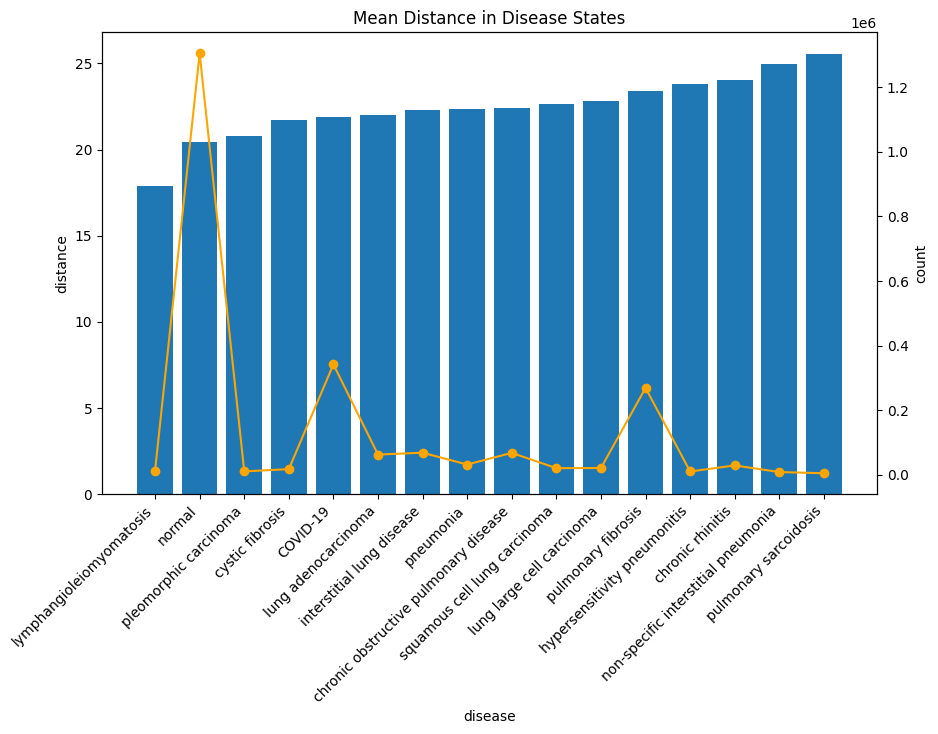

In [49]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(dist_by_disease["disease"], dist_by_disease["total_dist"])
ax1.set_xlabel("disease")
ax1.set_ylabel("distance")
ax1.set_xticks(range(len(dist_by_disease["disease"])))
ax1.set_xticklabels(dist_by_disease["disease"], rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(count_by_disease["size"], marker='o', color='orange')
ax2.set_ylabel("count")

plt.title("Mean Distance in Disease States")
plt.show()

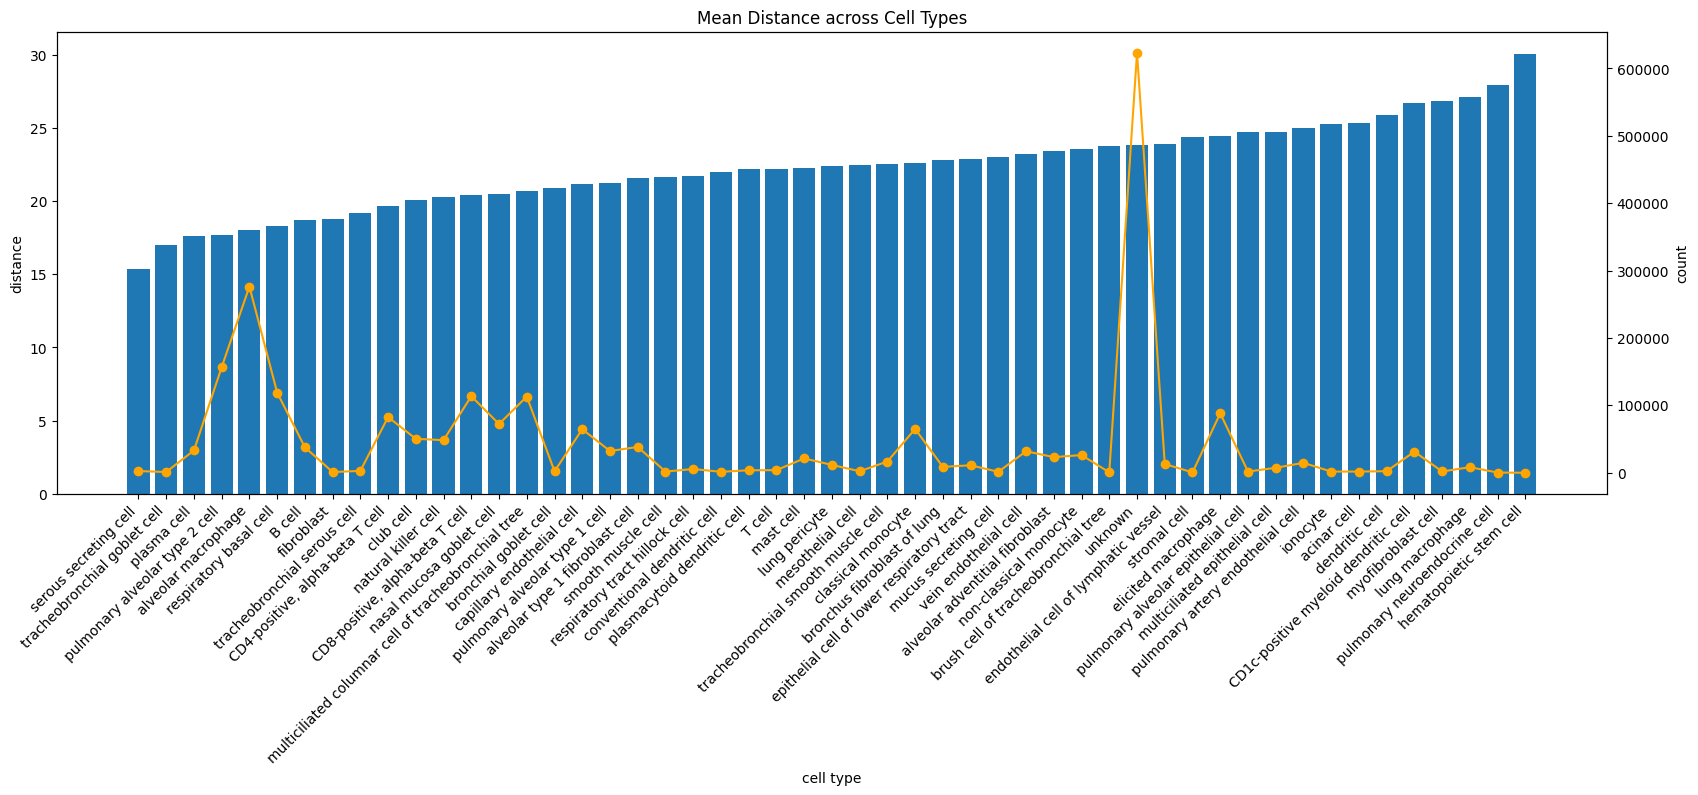

In [48]:
fig, ax1 = plt.subplots(figsize=(20, 6))

ax1.bar(dist_by_cell["cell_type"], dist_by_cell["total_dist"])
ax1.set_xlabel("cell type")
ax1.set_ylabel("distance")
ax1.set_xticks(range(len(dist_by_cell["cell_type"])))
ax1.set_xticklabels(dist_by_cell["cell_type"], rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(count_by_cell["size"], marker='o', color='orange')
ax2.set_ylabel("count")

plt.title("Mean Distance across Cell Types")
plt.show()

In [52]:
umap = UMAP()
umap.fit(file["trajectory"]["0"])

,n_neighbors,15
,n_components,2
,metric,'euclidean'
,metric_kwds,None
,output_metric,'euclidean'
,output_metric_kwds,None
,n_epochs,None
,learning_rate,1.0
,init,'spectral'
,min_dist,0.1
,spread,1.0


In [53]:
labels, colors = np.unique(adata.obs["disease"], return_inverse=True)
labels

array(['COVID-19', 'chronic obstructive pulmonary disease',
       'chronic rhinitis', 'cystic fibrosis',
       'hypersensitivity pneumonitis', 'interstitial lung disease',
       'lung adenocarcinoma', 'lung large cell carcinoma',
       'lymphangioleiomyomatosis', 'non-specific interstitial pneumonia',
       'normal', 'pleomorphic carcinoma', 'pneumonia',
       'pulmonary fibrosis', 'pulmonary sarcoidosis',
       'squamous cell lung carcinoma'], dtype=object)

In [63]:
np.unique(colors)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])

In [64]:
normal_idx = np.where(colors == 10)
disease_idx = np.where(colors == 14)

In [65]:
normal_cells = []
disease_cells = []

for i in range(21):
    normal_cells.append(umap.transform(np.array(file["trajectory"][f"{i}"])[normal_idx]))
    disease_cells.append(umap.transform(np.array(file["trajectory"][f"{i}"])[disease_idx]))

In [ ]:
normal_cells = np.stack(normal_cells)
disease_cells = np.stack(disease_cells)

In [83]:
normal_cells = np.permute_dims(normal_cells, (1, 0, 2))
disease_cells = np.permute_dims(disease_cells, (1, 0, 2))

In [84]:
normal_cells[0]

array([[ 8.617669 , -6.490688 ],
       [ 8.644981 , -6.511283 ],
       [ 8.6338625, -6.5284204],
       [ 8.651678 , -6.54895  ],
       [ 8.654423 , -6.51767  ],
       [ 8.662504 , -6.53868  ],
       [ 8.641637 , -6.5503497],
       [ 8.649702 , -6.57481  ],
       [ 8.650024 , -6.5644226],
       [ 8.657317 , -6.5405273],
       [ 8.63979  , -6.570434 ],
       [ 8.653429 , -6.539115 ],
       [ 8.646009 , -6.539844 ],
       [ 8.646184 , -6.539178 ],
       [ 8.647845 , -6.534759 ],
       [ 8.653088 , -6.5381274],
       [ 8.653553 , -6.536397 ],
       [ 8.651243 , -6.5413017],
       [ 8.654734 , -6.543838 ],
       [ 8.6652155, -6.57295  ],
       [ 8.653911 , -6.5308185]], dtype=float32)

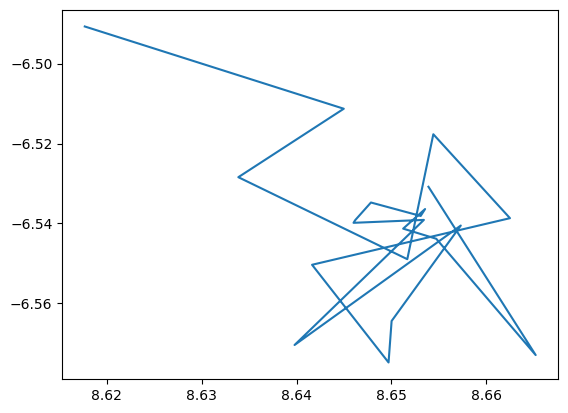

In [92]:
plt.plot(normal_cells[0, :, 0], normal_cells[0, :, 1])

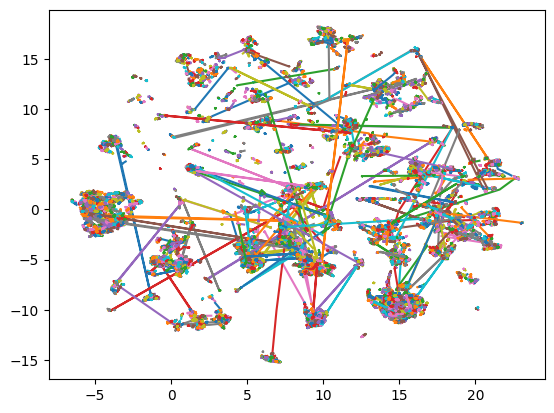

In [103]:
for i in range(10000):
    plt.plot(normal_cells[i, :, 0], normal_cells[i, :, 1])

plt.show()

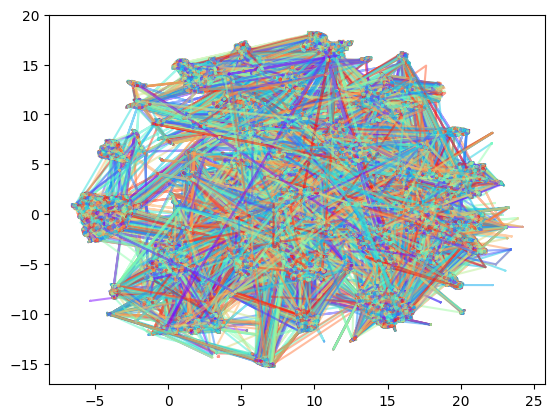

In [107]:
from matplotlib.collections import LineCollection

fig, ax = plt.subplots()

# Create an array of colors using a colormap
colors = plt.cm.rainbow(np.linspace(0, 1, len(normal_cells)))
np.random.shuffle(colors)

# normal_cells contains the x,y coordinates for each line
lines = LineCollection(normal_cells, alpha=0.5, colors=colors)
ax.add_collection(lines)
ax.autoscale()

plt.show()

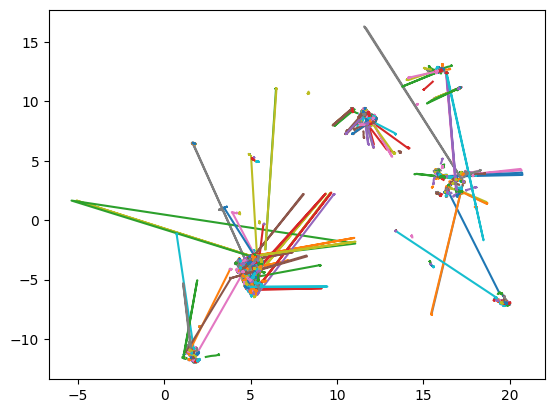

In [100]:
for i in range(len(disease_cells)):
    plt.plot(disease_cells[i, :, 0], disease_cells[i, :, 1])

plt.show()

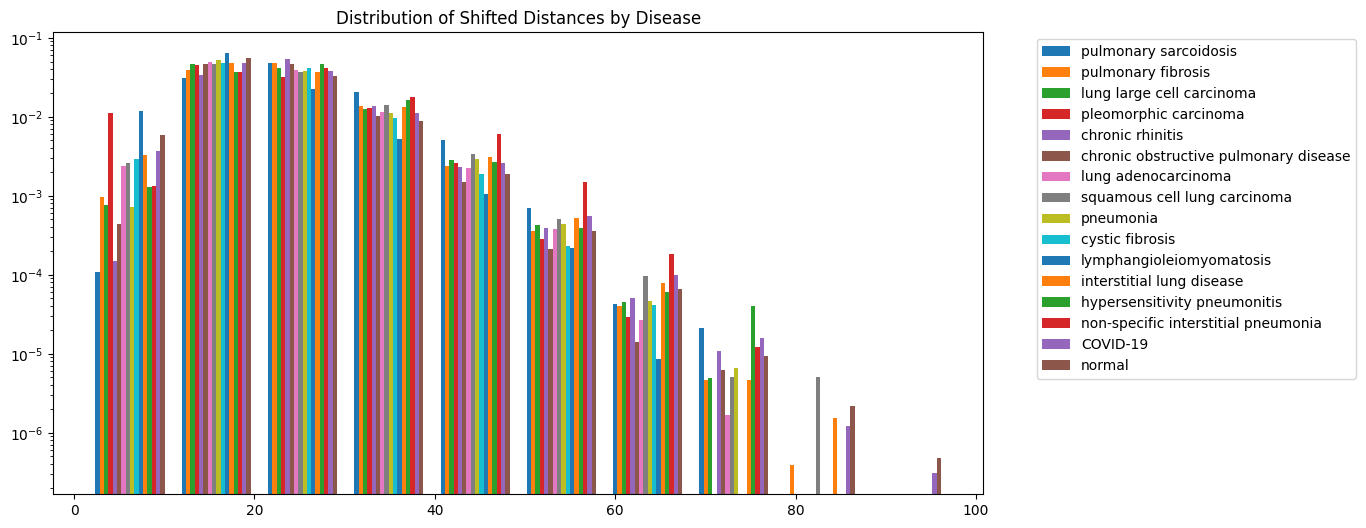

In [111]:
plt.figure(figsize=(12, 6))

datasets = [group["total_dist"].values for _, group in df.groupby("disease")]
labels = [name for name, _ in df.groupby("disease")]

plt.hist(datasets, bins=10, label=labels, histtype='bar', log=True, density=True)
plt.title("Distribution of Shifted Distances by Disease")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()